In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r'C:\Users\HP\Downloads\supply_chain_project\data\DataCoSupplyChainDataset.csv', encoding='latin-1')
print("Loaded:", df.shape)

Loaded: (180519, 53)


C:\Users\HP\AppData\Local\Temp\ipykernel_27528\2859335894.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ship_late.index, y=ship_late.values, palette='Reds_r')


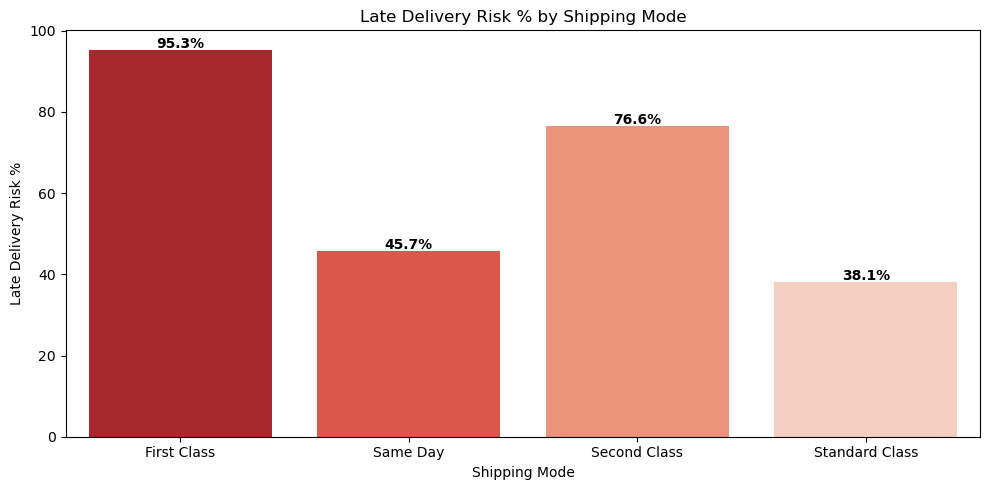

In [26]:
ship_late = df.groupby('Shipping Mode')['Late_delivery_risk'].mean() * 100

plt.figure(figsize=(10,5))
sns.barplot(x=ship_late.index, y=ship_late.values, palette='Reds_r')
plt.title('Late Delivery Risk % by Shipping Mode')
plt.xlabel('Shipping Mode')
plt.ylabel('Late Delivery Risk %')
for i, v in enumerate(ship_late.values):
    plt.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_27528\3206336807.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dept_profit.values, y=dept_profit.index, palette='Greens_r')


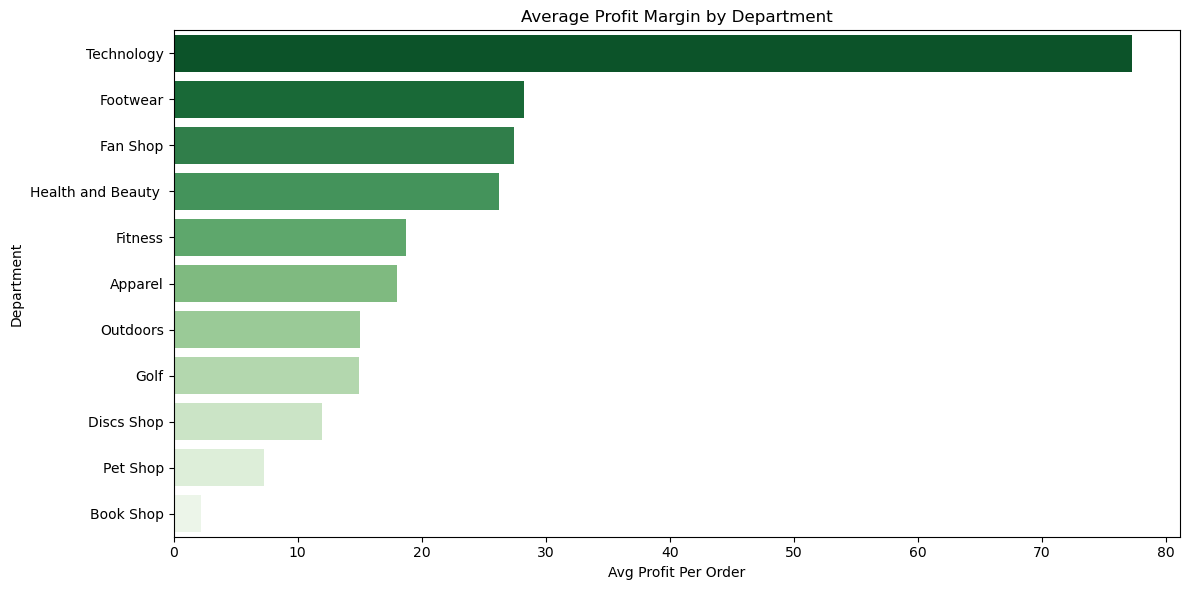

In [27]:
dept_profit = df.groupby('Department Name')['Order Profit Per Order'].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(x=dept_profit.values, y=dept_profit.index, palette='Greens_r')
plt.title('Average Profit Margin by Department')
plt.xlabel('Avg Profit Per Order')
plt.ylabel('Department')
plt.tight_layout()
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_27528\1182435062.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disc_profit = df.groupby('Discount_Band')['Order Profit Per Order'].mean()
C:\Users\HP\AppData\Local\Temp\ipykernel_27528\1182435062.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=disc_profit.index, y=disc_profit.values, palette='Blues_r')


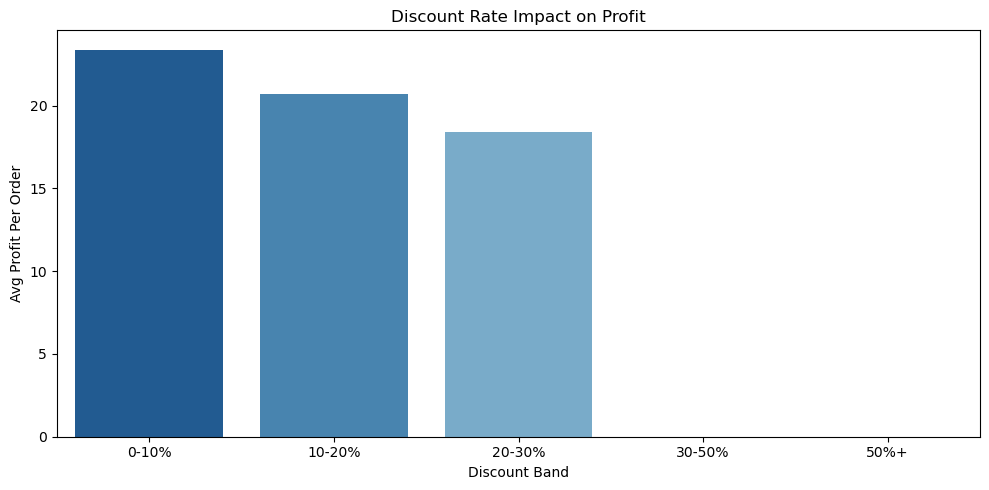

In [28]:
df['Discount_Band'] = pd.cut(df['Order Item Discount Rate'], 
                              bins=[0, 0.1, 0.2, 0.3, 0.5, 1.0],
                              labels=['0-10%','10-20%','20-30%','30-50%','50%+'])

disc_profit = df.groupby('Discount_Band')['Order Profit Per Order'].mean()

plt.figure(figsize=(10,5))
sns.barplot(x=disc_profit.index, y=disc_profit.values, palette='Blues_r')
plt.title('Discount Rate Impact on Profit')
plt.xlabel('Discount Band')
plt.ylabel('Avg Profit Per Order')
plt.tight_layout()
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_27528\3065912269.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=market_profit.index, y=market_profit.values, palette='Purples_r')


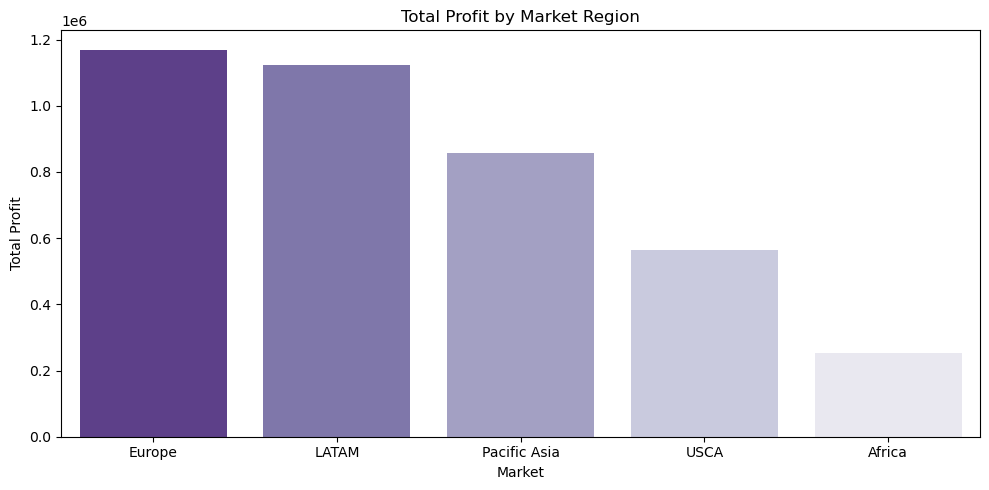

In [29]:
market_profit = df.groupby('Market')['Order Profit Per Order'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x=market_profit.index, y=market_profit.values, palette='Purples_r')
plt.title('Total Profit by Market Region')
plt.xlabel('Market')
plt.ylabel('Total Profit')
plt.tight_layout()
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_27528\4058482195.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=order_status.index, y=order_status.values, palette='Oranges_r')


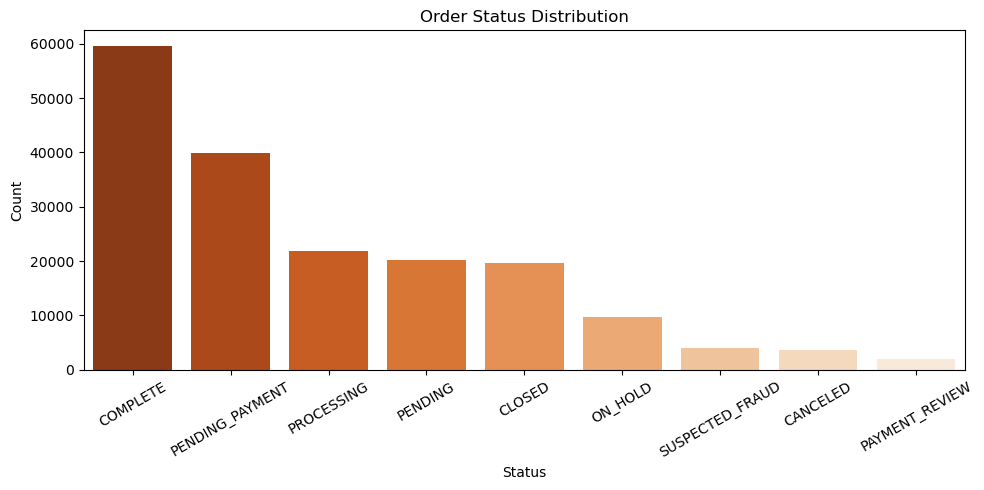

In [30]:
order_status = df['Order Status'].value_counts()

plt.figure(figsize=(10,5))
sns.barplot(x=order_status.index, y=order_status.values, palette='Oranges_r')
plt.title('Order Status Distribution')
plt.xlabel('Status')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

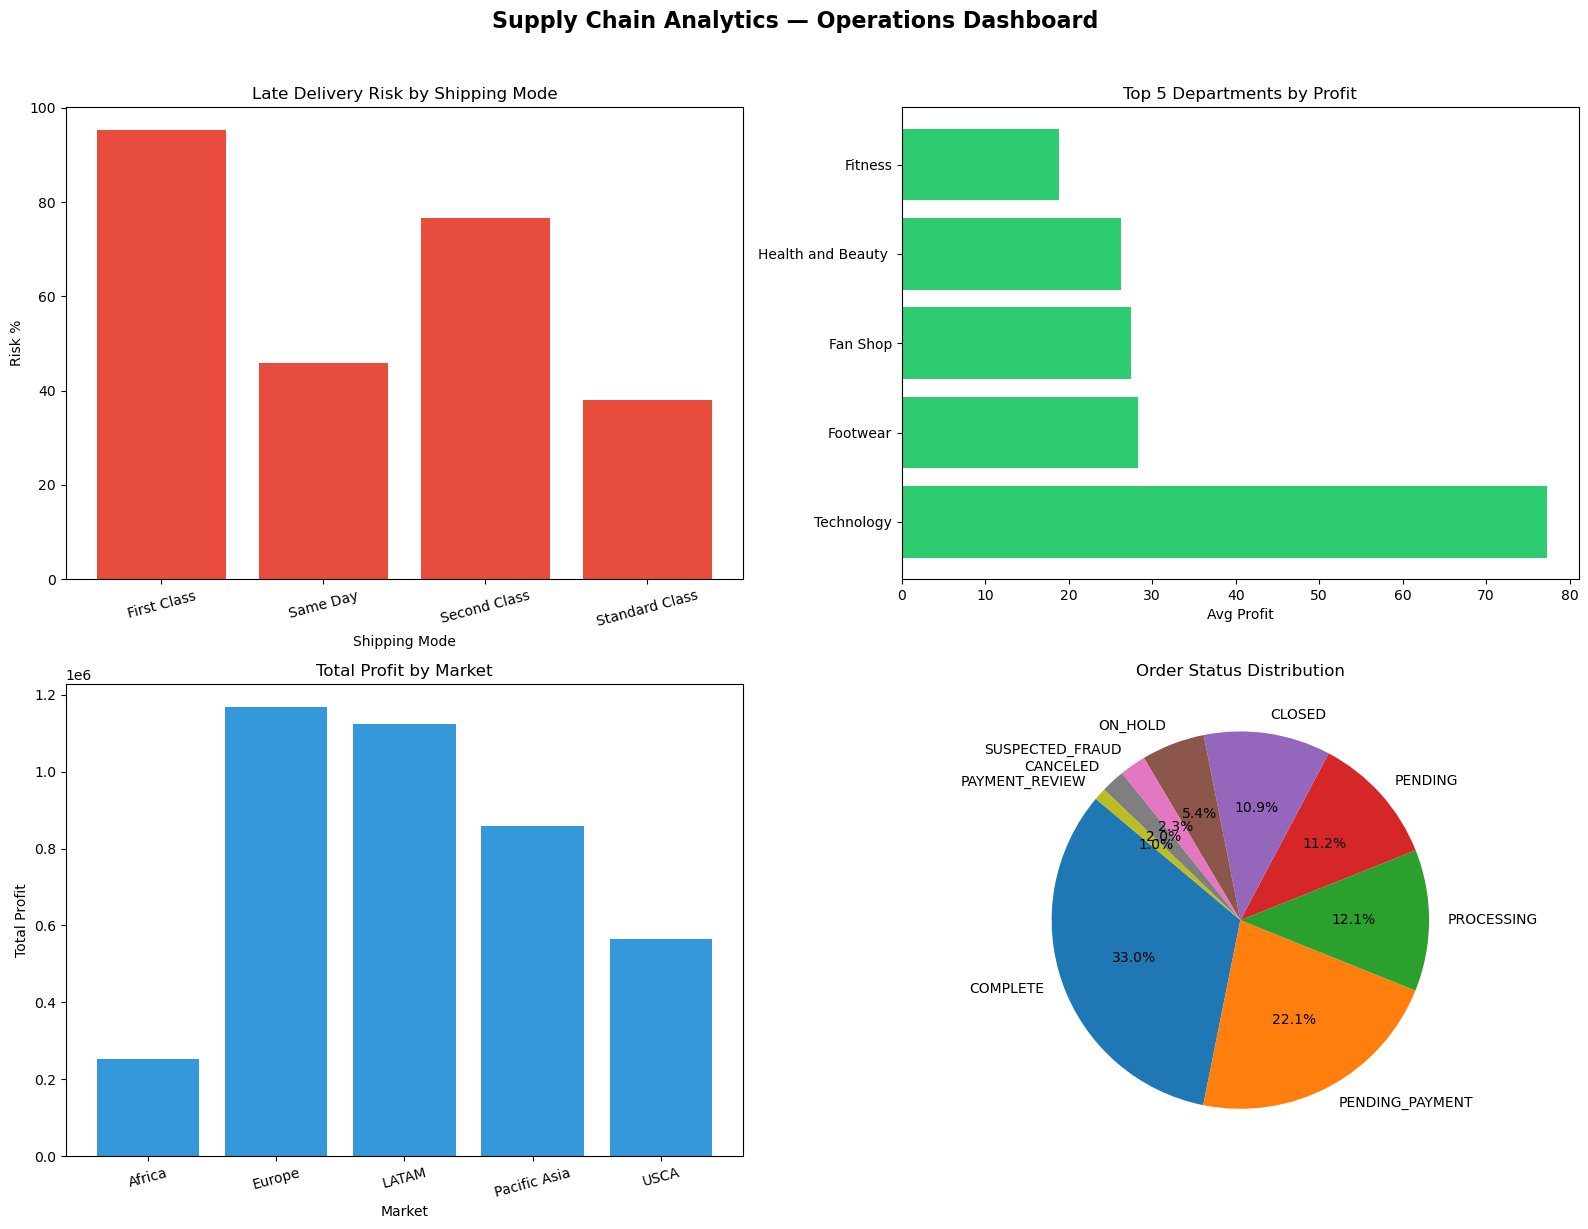

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Chart 1 - Late delivery by shipping
ship_late = df.groupby('Shipping Mode')['Late_delivery_risk'].mean() * 100
axes[0,0].bar(ship_late.index, ship_late.values, color='#e74c3c')
axes[0,0].set_title('Late Delivery Risk by Shipping Mode')
axes[0,0].set_xlabel('Shipping Mode')
axes[0,0].set_ylabel('Risk %')
axes[0,0].tick_params(axis='x', rotation=15)

# Chart 2 - Profit by department
dept_profit = df.groupby('Department Name')['Order Profit Per Order'].mean().sort_values(ascending=False).head(5)
axes[0,1].barh(dept_profit.index, dept_profit.values, color='#2ecc71')
axes[0,1].set_title('Top 5 Departments by Profit')
axes[0,1].set_xlabel('Avg Profit')

# Chart 3 - Market profit
market_profit = df.groupby('Market')['Order Profit Per Order'].sum()
axes[1,0].bar(market_profit.index, market_profit.values, color='#3498db')
axes[1,0].set_title('Total Profit by Market')
axes[1,0].set_xlabel('Market')
axes[1,0].set_ylabel('Total Profit')
axes[1,0].tick_params(axis='x', rotation=15)

# Chart 4 - Order status
order_status = df['Order Status'].value_counts()
axes[1,1].pie(order_status.values, labels=order_status.index, 
              autopct='%1.1f%%', startangle=140)
axes[1,1].set_title('Order Status Distribution')

plt.suptitle('Supply Chain Analytics — Operations Dashboard', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()